In [1]:
import ssl

ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
import copy
from pathlib import Path

import earthkit.plots
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
from numcodecs_combinators.stack import CodecStack
from numcodecs_safeguards import SafeguardedCodec
from numcodecs_wasm_ebcc import Ebcc
from numcodecs_wasm_zfp import Zfp

In [3]:
# most examples test SZ3 v3.3, but we want to test SZ3 v3.2
# but pip doesn't allow installing two different versions of the same package
# so we instead import the SZ3 v3.2 package directly from its PyPi wheel

import shutil
import sys
import tempfile
from urllib.request import urlopen
from zipfile import ZipFile

numcodecs_wasm_sz3_2_url = (
    "https://files.pythonhosted.org/packages/a0/c4/"
    + "8e0cdbda2ffd5a591bf31c15e274984e065dfbfff27a725acf481c2a2bde/"
    + "numcodecs_wasm_sz3-0.7.0-py3-none-any.whl"
)

with tempfile.TemporaryDirectory() as tmp:
    numcodecs_wasm_sz3_2_wheel = Path(tmp) / Path(numcodecs_wasm_sz3_2_url).name

    with urlopen(numcodecs_wasm_sz3_2_url) as response:
        with numcodecs_wasm_sz3_2_wheel.open("wb") as wheel:
            shutil.copyfileobj(response, wheel)

        with ZipFile(numcodecs_wasm_sz3_2_wheel, "r") as wheel:
            numcodecs_wasm_sz3_2_source = wheel.extractall(tmp)
            (Path(tmp) / "numcodecs_wasm_sz3").rename(
                Path(tmp) / "numcodecs_wasm_sz3_2"
            )
            sys.path.append(tmp)
            from numcodecs_wasm_sz3_2 import Sz3 as Sz3_2

            sys.path.remove(tmp)

In [4]:
wvpa = xr.open_dataset(
    Path() / "data" / "hoaps-c.r30.h06.wvpa.2020-08" / "data.nc",
    engine="netcdf4",
    decode_timedelta=True,
).wvpa.sel(time="2020-08-02")
wvpa.sizes

Frozen({'time': 4, 'lat': 320, 'lon': 720})

In [5]:
eb_abs = 0.1

In [6]:
zfp = Zfp(mode="fixed-accuracy", tolerance=eb_abs, non_finite="allow-unsafe")

wvpa_zfp_enc = zfp.encode(wvpa.values)
wvpa_zfp = wvpa.copy(deep=True, data=zfp.decode(wvpa_zfp_enc))
wvpa_zfp_cr = wvpa.nbytes / wvpa_zfp_enc.nbytes

In [7]:
sz3_2 = Sz3_2(eb_mode="abs", eb_abs=eb_abs)

wvpa_sz3_2_enc = sz3_2.encode(wvpa.values)
wvpa_sz3_2 = wvpa.copy(deep=True, data=sz3_2.decode(wvpa_sz3_2_enc))
wvpa_sz3_2_cr = wvpa.nbytes / np.asarray(wvpa_sz3_2_enc).nbytes

In [8]:
from numcodecs.abc import Codec
from numcodecs.compat import ndarray_copy


class MagicalNaNCodec(Codec):
    codec_id = "magic"

    def encode(self, buf):
        self.isnan = np.isnan(buf)
        return np.nan_to_num(buf, nan=np.nanmean(buf))

    def decode(self, buf, out=None):
        return ndarray_copy(np.where(self.isnan, np.nan, buf), out)

In [9]:
ebcc = CodecStack(
    MagicalNaNCodec(), Ebcc(base_cr=1000, residual="absolute", error=eb_abs)
)

wvpa_ebcc_enc = ebcc.encode(wvpa.values)
wvpa_ebcc = wvpa.copy(deep=True, data=ebcc.decode(wvpa_ebcc_enc))
wvpa_ebcc_cr = wvpa.nbytes / np.asarray(wvpa_ebcc_enc).nbytes

In [10]:
wvpa_sg = dict()
wvpa_sg_cr = dict()

for codec_id, codec in {
    zfp.codec_id: zfp,
    "sz3.2.rs": sz3_2,
    "ebcc.rs": ebcc,
}.items():
    sg = SafeguardedCodec(
        codec=codec, safeguards=[dict(kind="eb", type="abs", eb=eb_abs, equal_nan=True)]
    )

    wvpa_sg_enc = sg.encode(wvpa.values)
    wvpa_sg[codec_id] = wvpa.copy(deep=True, data=sg.decode(wvpa_sg_enc))
    wvpa_sg_cr[codec_id] = wvpa.nbytes / np.asarray(wvpa_sg_enc).nbytes

In [11]:
old_cmap_and_norm = earthkit.plots.styles.colors.cmap_and_norm

In [12]:
def my_cmap_and_norm(colors, levels, normalize=True, extend=None, extend_levels=True):
    return old_cmap_and_norm(colors, levels, normalize, extend, True)


earthkit.plots.styles.colors.cmap_and_norm = my_cmap_and_norm

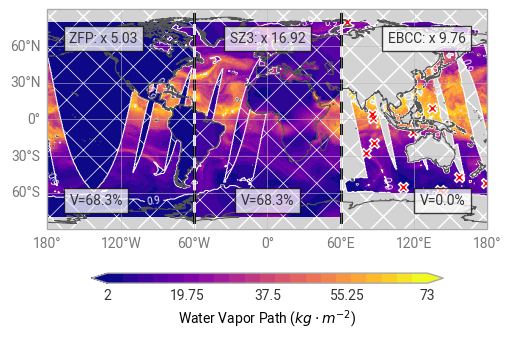

In [13]:
fig = earthkit.plots.Figure(
    size=(5, 5),
    rows=1,
    columns=1,
)

chart = fig.add_map(0, 0)

# compute the default style that earthkit.maps would apply
source = earthkit.plots.sources.XarraySource(wvpa)
style = copy.deepcopy(
    earthkit.plots.styles.auto.guess_style(
        source,
        units=source.units,
    )
)
style._levels = earthkit.plots.styles.levels.Levels(np.linspace(2, 73, 22))
style._legend_kwargs["ticks"] = np.linspace(2, 73, 5)
style._legend_kwargs["extend"] = "both"

chart.ax.fill_between(
    [0, 1],
    [1, 1],
    hatch="X",
    edgecolor="white",
    facecolor="lightgrey",
    transform=chart.ax.transAxes,
    zorder=-12,
)

# ZFP
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(-180, -60))
dac = wvpa_zfp.sel(time="2020-08-02T06:00", lon=slice(-180, -60))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.05,
    0.9,
    f"ZFP: x {np.round(wvpa_zfp_cr, 2)}",
    ha="left",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~((np.abs(wvpa_zfp - wvpa) <= eb_abs) | (np.isnan(wvpa_zfp) & np.isnan(wvpa)))
)
t = chart.ax.text(
    0.05,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="left",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

# SZ3.2
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(-60, 60))
dac = wvpa_sz3_2.sel(time="2020-08-02T06:00", lon=slice(-60, 60))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.5,
    0.9,
    f"SZ3: x {np.round(wvpa_sz3_2_cr, 2)}",
    ha="center",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~((np.abs(wvpa_sz3_2 - wvpa) <= eb_abs) | (np.isnan(wvpa_sz3_2) & np.isnan(wvpa)))
)
t = chart.ax.text(
    0.5,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="center",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

# EBCC
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(60, 180))
dac = wvpa_ebcc.sel(time="2020-08-02T06:00", lon=slice(60, 180))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.95,
    0.9,
    f"EBCC: x {np.round(wvpa_ebcc_cr, 2)}",
    ha="right",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~((np.abs(wvpa_ebcc - wvpa) <= eb_abs) | (np.isnan(wvpa_ebcc) & np.isnan(wvpa)))
)
t = chart.ax.text(
    0.95,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="right",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

da = wvpa.sel(time="2020-08-02T06:00")
chart.contour(
    x=np.broadcast_to(
        da.lon.values.reshape(1, -1),
        da.shape,
    ),
    y=np.broadcast_to(
        da.lat.values.reshape(-1, 1),
        da.shape,
    ),
    z=np.isnan(da).values,
    colors=["none"],
    linecolors=["white"],
    levels=[-0.5, 0.9, 1.5],
    legend_style=None,
    zorder=-10,
)

chart.ax.set_rasterization_zorder(-10)

chart.ax.axvline(-60, c="white", ls=(2, (4, 4)), lw=2)
chart.ax.axvline(-60, c="black", ls=(6, (4, 4)), lw=2)
chart.ax.axvline(+60, c="white", ls=(2, (4, 4)), lw=2)
chart.ax.axvline(+60, c="black", ls=(6, (4, 4)), lw=2)

for m in earthkit.plots.schemas.schema.quickmap_subplot_workflow:
    if m != "title":
        getattr(chart, m)()

for m in earthkit.plots.schemas.schema.quickmap_figure_workflow:
    if m != "legend":
        getattr(chart, m)()

chart.legend()

fig.save("summary-nan.pdf")

/var/folders/8v/swxsmn0d4vz5yzwjhf6bc26x3g7lq6/T/ipykernel_13273/512359589.py:34: RuntimeWarning: invalid value encountered in subtract
  is_error = np.abs(da.values - dac.values) > eb_abs
/var/folders/8v/swxsmn0d4vz5yzwjhf6bc26x3g7lq6/T/ipykernel_13273/512359589.py:113: RuntimeWarning: invalid value encountered in subtract
  is_error = np.abs(da.values - dac.values) > eb_abs


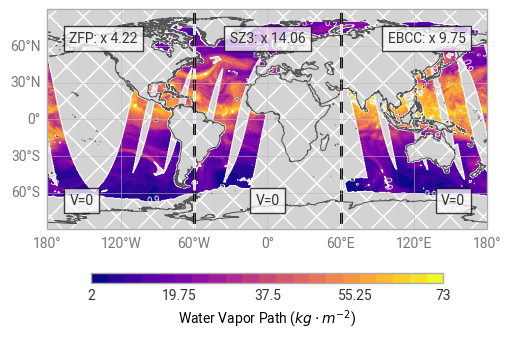

In [14]:
fig = earthkit.plots.Figure(
    size=(5, 5),
    rows=1,
    columns=1,
)

chart = fig.add_map(0, 0)

# compute the default style that earthkit.maps would apply
source = earthkit.plots.sources.XarraySource(wvpa)
style = copy.deepcopy(
    earthkit.plots.styles.auto.guess_style(
        source,
        units=source.units,
    )
)
style._levels = earthkit.plots.styles.levels.Levels(np.linspace(2, 73, 22))
style._legend_kwargs["ticks"] = np.linspace(2, 73, 5)
style._legend_kwargs["extend"] = "neither"

chart.ax.fill_between(
    [0, 1],
    [1, 1],
    hatch="X",
    edgecolor="white",
    facecolor="lightgrey",
    transform=chart.ax.transAxes,
    zorder=-12,
)

# ZFP
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(-180, -60))
dac = wvpa_sg["zfp.rs"].sel(time="2020-08-02T06:00", lon=slice(-180, -60))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.05,
    0.9,
    f"ZFP: x {np.round(wvpa_sg_cr['zfp.rs'], 2)}",
    ha="left",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~(
        (np.abs(wvpa_sg["zfp.rs"] - wvpa) <= eb_abs)
        | (np.isnan(wvpa_sg["zfp.rs"]) & np.isnan(wvpa))
    )
)
t = chart.ax.text(
    0.05,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="left",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

# SZ3.2
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(-60, 60))
dac = wvpa_sg["sz3.2.rs"].sel(time="2020-08-02T06:00", lon=slice(-60, 60))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.5,
    0.9,
    f"SZ3: x {np.round(wvpa_sg_cr['sz3.2.rs'], 2)}",
    ha="center",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~(
        (np.abs(wvpa_sg["sz3.2.rs"] - wvpa) <= eb_abs)
        | (np.isnan(wvpa_sg["sz3.2.rs"]) & np.isnan(wvpa))
    )
)
t = chart.ax.text(
    0.5,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="center",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

# EBCC
da = wvpa.sel(time="2020-08-02T06:00", lon=slice(60, 180))
dac = wvpa_sg["ebcc.rs"].sel(time="2020-08-02T06:00", lon=slice(60, 180))
is_error = np.abs(da.values - dac.values) > eb_abs
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.pcolormesh(dac, style=style, zorder=-11)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    linewidths=3,
    s=40,
    legend_style=None,
    marker="x",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="red",
    linewidths=1,
    s=20,
    legend_style=None,
    marker="x",
)

with plt.rc_context(
    {
        "hatch.color": "white",
        "hatch.linewidth": 0.5,
    }
):
    chart.contourf(
        x=np.broadcast_to(
            da.lon.values.reshape(1, -1),
            da.shape,
        ),
        y=np.broadcast_to(
            da.lat.values.reshape(-1, 1),
            da.shape,
        ),
        z=np.isnan(da).values,
        colors=["none"],
        levels=[-0.5, 0.9, 1.5],
        hatches=[None, "X"],
        legend_style=None,
        zorder=-10,
    )

t = chart.ax.text(
    0.95,
    0.9,
    f"EBCC: x {np.round(wvpa_sg_cr['ebcc.rs'], 2)}",
    ha="right",
    va="top",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

err_v = np.mean(
    ~(
        (np.abs(wvpa_sg["ebcc.rs"] - wvpa) <= eb_abs)
        | (np.isnan(wvpa_sg["ebcc.rs"]) & np.isnan(wvpa))
    )
)
t = chart.ax.text(
    0.95,
    0.1,
    f"V={0 if err_v == 0 else np.format_float_positional(100 * err_v, precision=1, min_digits=1) + '%'}",
    ha="right",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

da = wvpa.sel(time="2020-08-02T06:00")
chart.contour(
    x=np.broadcast_to(
        da.lon.values.reshape(1, -1),
        da.shape,
    ),
    y=np.broadcast_to(
        da.lat.values.reshape(-1, 1),
        da.shape,
    ),
    z=np.isnan(da).values,
    colors=["none"],
    linecolors=["white"],
    levels=[-0.5, 0.9, 1.5],
    legend_style=None,
    zorder=-10,
)

chart.ax.set_rasterization_zorder(-10)

chart.ax.axvline(-60, c="white", ls=(2, (4, 4)), lw=2)
chart.ax.axvline(-60, c="black", ls=(6, (4, 4)), lw=2)
chart.ax.axvline(+60, c="white", ls=(2, (4, 4)), lw=2)
chart.ax.axvline(+60, c="black", ls=(6, (4, 4)), lw=2)

for m in earthkit.plots.schemas.schema.quickmap_subplot_workflow:
    if m != "title":
        getattr(chart, m)()

for m in earthkit.plots.schemas.schema.quickmap_figure_workflow:
    if m != "legend":
        getattr(chart, m)()

chart.legend()

fig.save("summary-nan-sg.pdf")